# Quantitative Analysis

**Objective**  
Perform technical analysis on AAPL, GOOG, META, MSFT, and NVDA using:
- Rolling statistics & custom indicators
- Beautiful visualizations (matplotlib + plotly)

---

## 1. Imports & Setup

In [1]:
import sys
import os
# Add project root (one directory above "notebooks")
sys.path.append(os.path.abspath(".."))

In [2]:
# import necessary modules from scripts
from scripts.load_data import load_stock_data
from scripts.technical_indicators import add_ta_indicators
from scripts.financial_metrics import (
    compute_returns,
    compute_volatility,
    compute_sharpe,
    compute_drawdown
)
from scripts.visualization import plot_price_and_sma, plot_rsi, plot_macd, plot_volatility, plot_drawdown


In [4]:
# Define your data paths in one place (easy to maintain)
DATA_PATHS = {
    'AAPL': '../data/AAPL.csv',
    'GOOG': '../data/GOOG.csv',
    'META': '../data/META.csv',
    'MSFT': '../data/MSFT.csv',
    'NVDA': '../data/NVDA.csv'
}

# One-liner to load everything!
stocks = load_stock_data(DATA_PATHS)

# Quick check
print(stocks['Ticker'].value_counts())
print(f"Total rows: {len(stocks)}")
stocks.tail(10)

Ticker
AAPL    3774
GOOG    3774
MSFT    3774
NVDA    3774
META    2923
Name: count, dtype: int64
Total rows: 18019


,Date,Open,High,Low,Close,Volume,Ticker
18009,2023-12-28,192.323710,192.838849,191.362784,191.768951,34049900,AAPL
18010,2023-12-28,140.885881,141.303025,139.870824,140.319748,12192500,GOOG
18011,2023-12-28,357.496184,359.682686,355.617749,356.124634,11798800,META
18012,2023-12-28,370.547702,371.623696,369.353256,370.458862,14327000,MSFT
18013,2023-12-28,49.618126,49.859003,49.387239,49.497185,246587000,NVDA
18014,2023-12-29,192.085953,192.581275,189.936256,190.728775,42672100,AAPL
18015,2023-12-29,139.723837,140.473710,138.949139,139.972137,14881000,GOOG
18016,2023-12-29,356.790470,357.794292,349.664418,351.791290,14987100,META
18017,2023-12-29,371.169703,372.314805,368.682088,371.209198,18730800,MSFT
18018,2023-12-29,49.788039,49.971949,48.726571,49.497185,389293000,NVDA


## 2. Technical Indicators
- **Simple Moving Average (SMA):** 20-day and 50-day
- **Exponential Moving Average (EMA):** 20-day
- **Relative Strength Index (RSI):** 14-daily       
RSI > 70 → asset is overbought (might drop soon).RSI < 30 → asset is oversold (might rise soon).
- **Moving Average Convergence Divergence (MACD):** 12, 26, 9

In [5]:
# compute technical indicators like sma,ema,rsi and macd and add them as columns to stocks_f
stocks_f = add_ta_indicators(stocks)
stocks_f.head(20) #quick check

,Date,Open,High,Low,Close,Volume,Ticker,SMA_20,SMA_50,EMA_20,RSI_14,MACD_12_26_9,MACD_hist_12_26_9,MACD_signal_12_26_9
0,2009-01-02,2.575630,2.730385,2.554037,2.721686,746015200,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-05,2.794266,2.884539,2.780469,2.836553,1181608400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-06,2.877641,2.914229,2.770872,2.789767,1289310400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-07,2.753477,2.774170,2.706990,2.729484,753048800,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-08,2.712090,2.793666,2.700393,2.780169,673500800,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2009-01-09,2.795466,2.800564,2.703393,2.716589,546845600,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2009-01-12,2.712990,2.728886,2.625717,2.659007,617716400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2009-01-13,2.646409,2.691395,2.589726,2.630514,798397600,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2009-01-14,2.586427,2.616717,2.540840,2.559135,1021664000,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2009-01-15,2.416377,2.522846,2.400782,2.500652,1831634000,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Financial Metrics
### Key Metrics Explained:
- **Sharpe Ratio**: Risk-adjusted return (higher = better; >1 is solid).
- **Sortino Ratio**: Like Sharpe but penalizes only downside volatility.
- **Max Drawdown**: Largest peak-to-trough drop (%).
- **Calmar Ratio**: Annual return / max drawdown (higher = more resilient).
- **Volatility**: Annualized std dev of returns.

These are computed on *daily returns* for accuracy. NVDA might show high Sharpe due to its 2023–2025 boom!

In [6]:
# compute financial metrics and add them as columns into stocks_f 
stocks_f = compute_returns(stocks_f)
stocks_f = compute_volatility(stocks_f, window=30)
sharpe_ratios = {}
for ticker, df_t in stocks_f.groupby("Ticker"):
    sharpe_ratios[ticker] = compute_sharpe(df_t)
sharpe_ratios

stocks_f = compute_drawdown(stocks_f)

In [7]:
cols_order = [
    'Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume',
    'SMA_20', 'SMA_50', 'EMA_20', 'RSI_14',
    'MACD_12_26_9', 'MACD_signal_12_26_9', 'MACD_hist_12_26_9',
    'return', 'log_return', 'vol_30', 'cum_return', 'running_max', 'drawdown'
]

# Apply reorder
stocks_f = stocks_f[cols_order]


# Quick Check
print(sharpe_ratios)
stocks_f

{'AAPL': np.float64(0.8878399419236348), 'GOOG': np.float64(-0.058500197436401113), 'META': np.float64(0.08903932892653675), 'MSFT': np.float64(-0.030694709690579237), 'NVDA': np.float64(-0.08233290965771742)}


,Date,Ticker,Open,High,Low,Close,Volume,SMA_20,SMA_50,EMA_20,RSI_14,MACD_12_26_9,MACD_signal_12_26_9,MACD_hist_12_26_9,return,log_return,vol_30,cum_return,running_max,drawdown
0,2009-01-02,AAPL,2.575630,2.730385,2.554037,2.721686,746015200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-05,AAPL,2.794266,2.884539,2.780469,2.836553,1181608400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.042204,0.041338,NaN,1.042204,1.042204,0.000000
2,2009-01-06,AAPL,2.877641,2.914229,2.770872,2.789767,1289310400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.016494,-0.016632,NaN,1.025014,1.042204,-0.016494
3,2009-01-07,AAPL,2.753477,2.774170,2.706990,2.729484,753048800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021609,-0.021845,NaN,1.002865,1.042204,-0.037746
4,2009-01-08,AAPL,2.712090,2.793666,2.700393,2.780169,673500800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.018570,0.018399,NaN,1.021488,1.042204,-0.019878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18014,2023-12-22,NVDA,49.170342,49.358247,48.442706,48.805527,252507000,47.706983,46.257777,48.024644,55.352119,0.634352,0.564438,0.069914,-0.003266,-0.003271,0.295430,17.932091,139.559938,-0.871510
18015,2023-12-26,NVDA,48.943454,49.575137,48.935459,49.254299,244200000,47.759019,46.334178,48.141754,57.245971,0.655689,0.582688,0.073001,0.009195,0.009153,0.284608,18.096978,139.559938,-0.870328
18016,2023-12-27,NVDA,49.486186,49.655100,49.060397,49.392231,233648000,47.838989,46.400666,48.260847,57.837928,0.675937,0.601338,0.074599,0.002800,0.002796,0.284255,18.147657,139.559938,-0.869965
18017,2023-12-28,NVDA,49.618126,49.859003,49.387239,49.497185,246587000,47.908266,46.512367,48.378593,58.310919,0.692470,0.619564,0.072906,0.002125,0.002123,0.277584,18.186219,139.559938,-0.869689


## 2. Visualize the Data

In this section, we explore and visualize the stock price data along with the technical indicators and financial metrics calculated previously. Visualizations help us understand:

- **Price Trends**: Line charts showing daily Close prices for each stock.
- **Technical Indicators**:
  - SMA_20, SMA_50, EMA_20 overlaid on price charts to show moving average trends.
  - RSI_14 plotted as a separate line chart to identify overbought/oversold conditions.
  - MACD_12_26_9 along with MACD signal and histogram to visualize momentum changes.
- **Volatility**: Rolling volatility (vol_30) plotted over time to identify periods of high and low risk.
- **Returns & Drawdowns**:
  - Cumulative returns and drawdown charts to highlight performance and risk exposure.
- **Scatter/Correlation plots** (optional): Show relationship between indicators (e.g., RSI vs returns).

All plotting functions are modularized in `scripts/visualizations.py` and handle NaN values from initial indicator calculations to ensure clean, readable graphs.


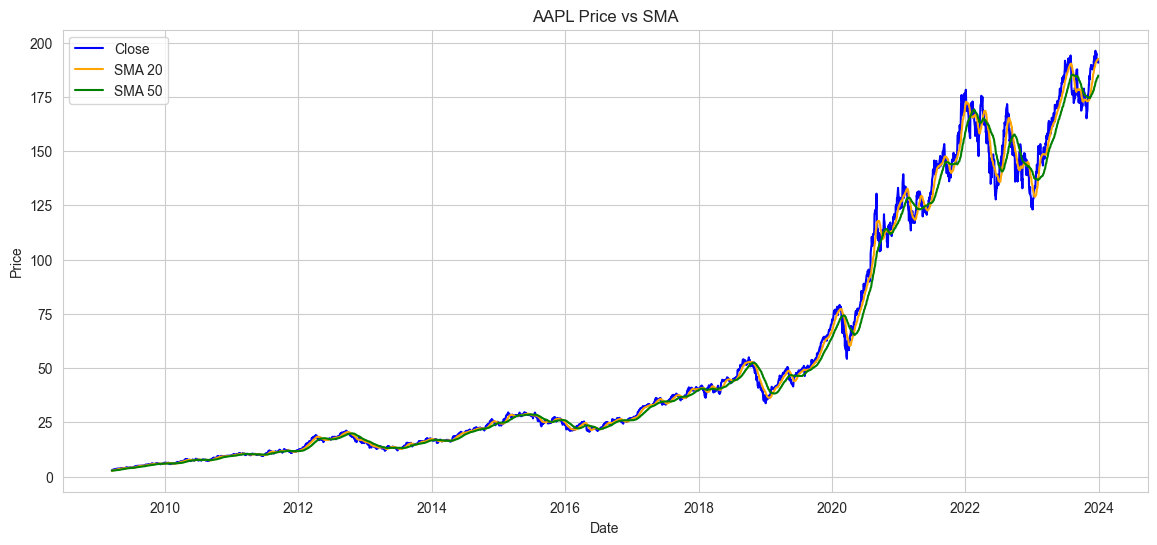

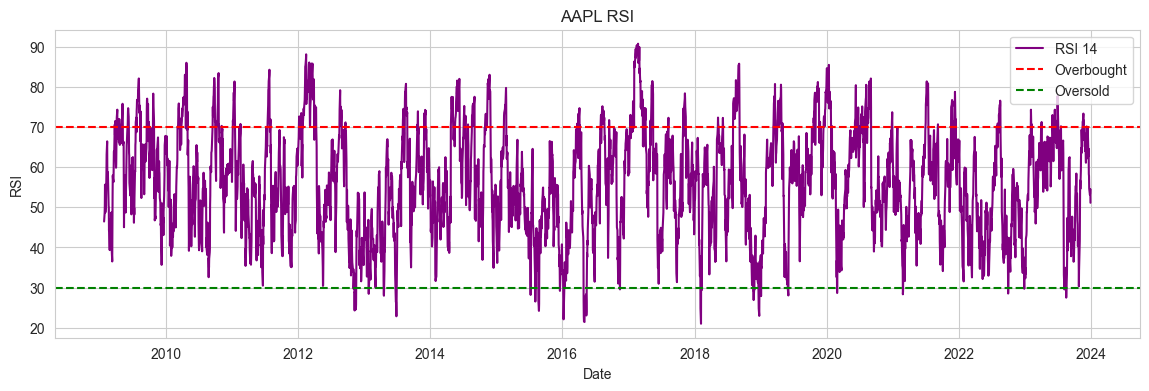

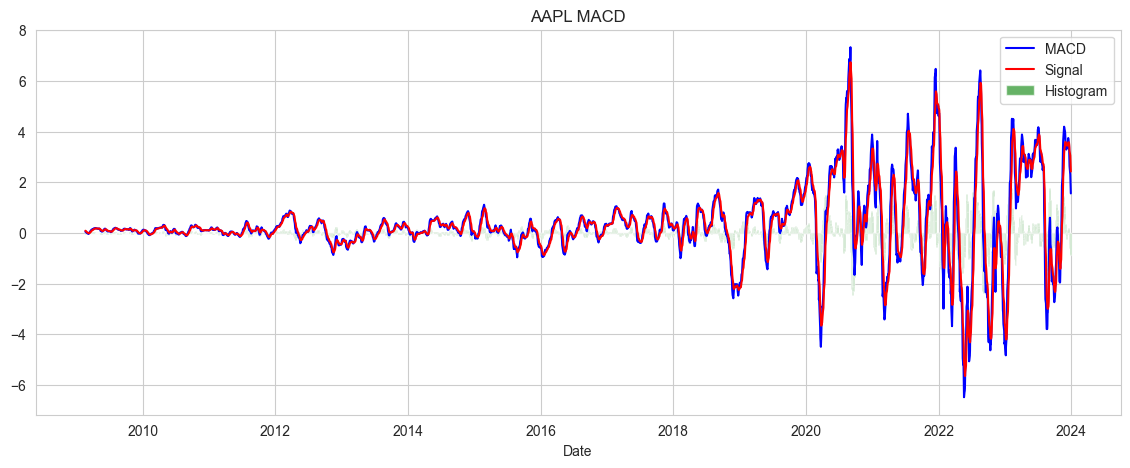

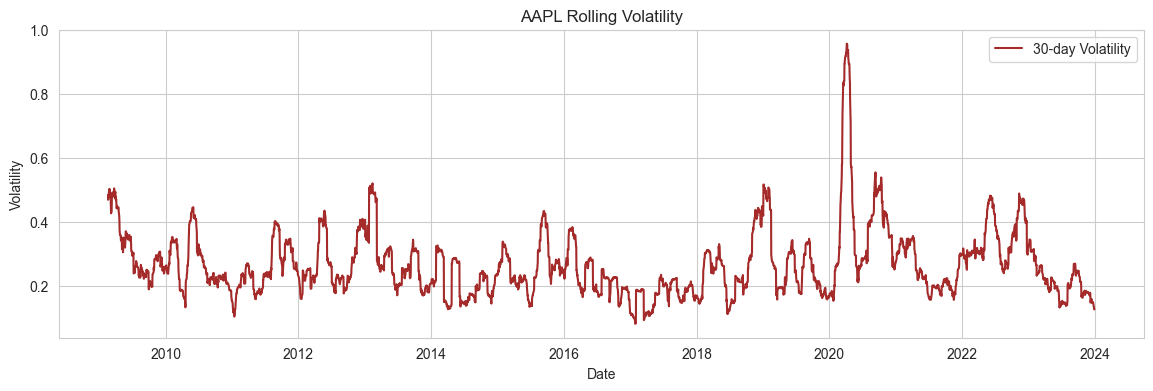

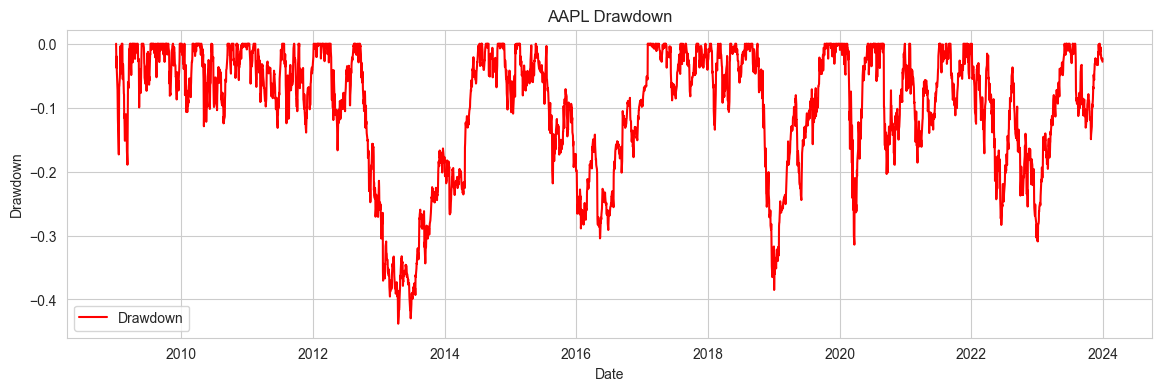

In [8]:
# visualization for aapl, to change the ticker simply rename the string eg. ticker='GOOG'
ticker = "AAPL"


# plot Price vs SMA
plot_price_and_sma(stocks_f, ticker)

# plot RSI
plot_rsi(stocks_f, ticker)

#plot MACD
plot_macd(stocks_f, ticker)

# plot rolling volatility
plot_volatility(stocks_f, ticker)

# plot drawdown
plot_drawdown(stocks_f, ticker)

In [ ]:
# Save final data frame as csv for 
stocks_f.to_csv("../data/processed/stocks_full.csv")